# SH518880 逐笔主动成交量分布

本 notebook 只读取 `code/active_trade_volume_distribution.py` 生成的 CSV 结果，不在 notebook 内做原始数据处理。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parent
DATA_DIR = ROOT / "data"

headline = pd.read_csv(DATA_DIR / "active_trade_volume_headline.csv")
quantiles = pd.read_csv(DATA_DIR / "active_trade_volume_quantiles.csv")
side = pd.read_csv(DATA_DIR / "active_trade_volume_side.csv")
second_mix = pd.read_csv(DATA_DIR / "active_trade_volume_second_mix.csv")
spread = pd.read_csv(DATA_DIR / "active_trade_volume_spread.csv")
time_bucket = pd.read_csv(DATA_DIR / "active_trade_volume_time_bucket.csv")
tail = pd.read_csv(DATA_DIR / "active_trade_volume_tail.csv")
hist = pd.read_csv(DATA_DIR / "active_trade_volume_hist.csv")
round_lot = pd.read_csv(DATA_DIR / "active_trade_volume_round_lot.csv")

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
display(headline)
display(quantiles)
display(side)
display(second_mix)
display(tail)
display(round_lot.head(15))

,instrument_id,trade_days,snapshots,active_seconds,active_second_ratio,event_count,buy_event_ratio,sell_event_ratio,total_event_volume,median_event_volume,p90_event_volume,p99_event_volume,median_active_second_volume,p90_active_second_volume
0,518880,49,705380,659536,0.935008,1351624,0.512718,0.487282,3.581444e+10,6000.0,68400.0,287600.0,14500.0,141000.0


,scope,q000,q10,q25,q50,q75,q90,q95,q99,q999,q100
0,all_events,1.0,300.0,1300.0,6000.0,22600.0,68400.0,116000.0,287600.0,711437.7,24341216.0
1,buy_events,8.0,300.0,1200.0,5700.0,21500.0,64600.0,111300.0,278100.0,698099.1,24341216.0
2,sell_events,1.0,400.0,1500.0,6300.0,24000.0,72500.0,120700.0,298200.0,729500.0,24341216.0
3,active_seconds,9.0,1000.0,3700.0,14500.0,54000.0,141000.0,231200.0,528000.0,1159893.0,49216432.0


,side,event_count,volume_sum,volume_share,mean_volume,median_volume,p90_volume,p99_volume
0,buy,693002,1.757345e+10,0.490681,25358.445931,5700.0,64600.0,278100.0
1,sell,658622,1.824099e+10,0.509319,27695.687343,6300.0,72500.0,298200.0


,second_type,seconds,ratio,mean_second_volume,median_second_volume,p90_second_volume
0,both_sides,410306,0.581681,76018.409265,27700.0,192300.0
1,buy_only,138862,0.196861,18409.132794,4300.0,46600.0
2,no_trade,45844,0.064992,0.000000,0.0,0.0
3,sell_only,110368,0.156466,18731.011761,4800.0,48000.0


,quantile,threshold_volume,event_ratio,volume_share,mean_tail_volume
0,0.900,68400.0,0.100082,0.620109,1.641780e+05
1,0.950,116000.0,0.050027,0.449150,2.378960e+05
2,0.990,287600.0,0.010001,0.188001,4.980886e+05
3,0.999,711437.7,0.001000,0.050943,1.349472e+06


,volume,event_count,event_ratio,volume_sum,volume_share
0,100.0,66128,0.048925,6612800.0,0.000185
1,200.0,41707,0.030857,8341400.0,0.000233
2,300.0,28721,0.021249,8616300.0,0.000241
3,400.0,21677,0.016038,8670800.0,0.000242
4,500.0,33290,0.024630,16645000.0,0.000465
5,600.0,19515,0.014438,11709000.0,0.000327
6,700.0,15072,0.011151,10550400.0,0.000295
7,800.0,13892,0.010278,11113600.0,0.000310
8,900.0,14861,0.010995,13374900.0,0.000373
9,1000.0,39456,0.029192,39456000.0,0.001102


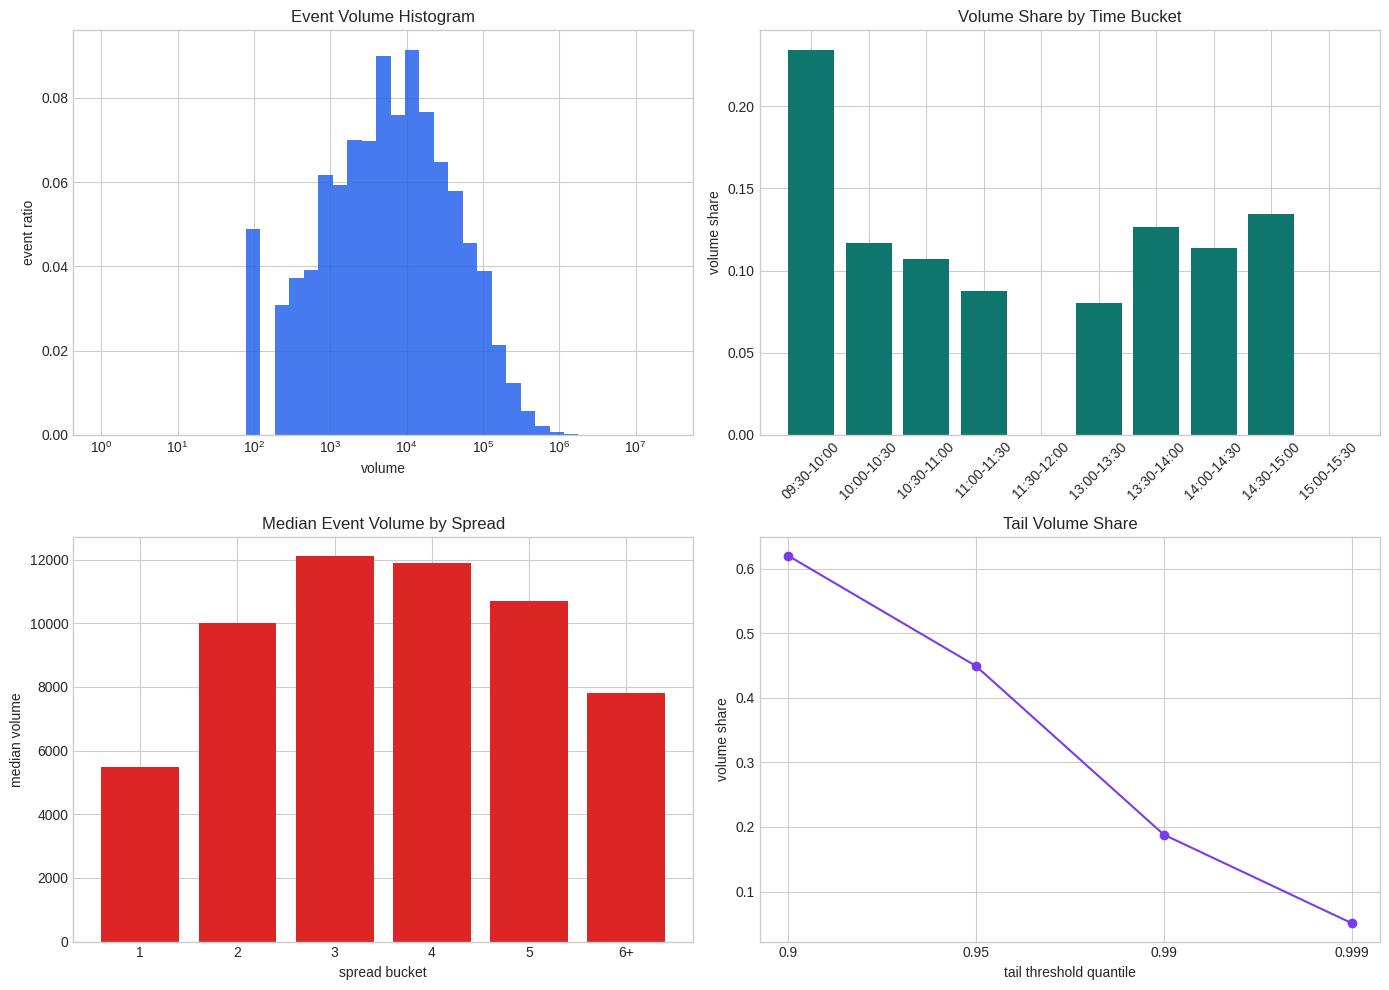

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

centers = (hist["bin_left"] + hist["bin_right"]) / 2
axes[0, 0].bar(centers, hist["event_ratio"], width=hist["bin_right"] - hist["bin_left"], color="#2563eb", alpha=0.85)
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("Event Volume Histogram")
axes[0, 0].set_xlabel("volume")
axes[0, 0].set_ylabel("event ratio")

axes[0, 1].bar(time_bucket["bucket_30m"], time_bucket["volume_share"], color="#0f766e")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].set_title("Volume Share by Time Bucket")
axes[0, 1].set_ylabel("volume share")

axes[1, 0].bar(spread["spread_bucket"], spread["median_volume"], color="#dc2626")
axes[1, 0].set_title("Median Event Volume by Spread")
axes[1, 0].set_xlabel("spread bucket")
axes[1, 0].set_ylabel("median volume")

axes[1, 1].plot(tail["quantile"].astype(str), tail["volume_share"], marker="o", color="#7c3aed")
axes[1, 1].set_title("Tail Volume Share")
axes[1, 1].set_xlabel("tail threshold quantile")
axes[1, 1].set_ylabel("volume share")

fig.tight_layout()
